# Part 1: In-silico spatial perturbation on the PerturbFISH dataset

This notebook performs **in silico spatial perturbation analysis** on the **PerturbFISH** dataset using a trained **SpiderNet** model and the processed dataset generated in the training stage.  
Its main goal is to predict how selected perturbations reshape **spatial communication patterns**, **meta-interactions (MIs)**, and downstream **T-cell response programs**, and to compare these predictions with the observed perturbation effects in the data.

Specifically, this notebook:

1. **Loads the trained SpiderNet model and processed PerturbFISH data**  
   Import the trained model, the processed dataset, and the metadata required for downstream perturbation analysis.

2. **Performs in silico spatial perturbation for selected perturbation genes**  
   Simulate the spatial effects of a predefined perturbation-gene set using the trained SpiderNet model.

3. **Summarizes predicted T-cell responses**  
   Quantify the predicted perturbation-induced changes in **T-cell-related responses** and organize them for downstream comparison and interpretation.

4. **Compares predicted and observed perturbation effects**  
   Evaluate how well the model-predicted response patterns match the perturbation effects observed in the original dataset.

5. **Interprets perturbation-induced communication changes**  
   Examine changes in **MI activity**, associated **ligand–receptor (LR)** and **target-gene programs**, and selected downstream marker patterns to understand the biological effects captured by the model.

Overall, this notebook serves as the **in silico perturbation analysis stage** of the PerturbFISH pipeline. It translates the trained SpiderNet representations into interpretable predictions about how perturbations alter **cell–cell communication**, **MI programs**, and downstream **cell-state responses**.

## 1. Imports and device setup

In [1]:
import json
import pickle
import sys
from pathlib import Path

import gseapy as gp
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import torch

# Optional: add your local project root if SpiderNet is not already importable.
# PROJECT_ROOT = Path(r"D:/SpiderNet/SpiderNet_proj")
# if str(PROJECT_ROOT) not in sys.path:
#     sys.path.append(str(PROJECT_ROOT))

from SpiderNet.config import PathConfig, PreprocessConfig, TrainingConfig
from SpiderNet.io import load_processed_data
from SpiderNet.api import build_model

# Make the helper modules in the same folder importable.
HELPER_DIR = Path.cwd()
if str(HELPER_DIR) not in sys.path:
    sys.path.append(str(HELPER_DIR))

from SpiderNet.analysis import (
    sanity_check_processed,
    load_part0_outputs,
    run_insilico_spatial_perturbation,
    compute_mi_change_tables,
    select_top_features_for_mi,
    select_perturb_genes_for_mi,
    build_edge_group_masks_for_selected_genes,
    build_tcell_subset_from_edge_groups,
    compute_mi_receiver_agg_max,
)
from SpiderNet.visualization import (
    apply_publication_style,
    plot_gene_correlation_barplot,
    plot_mi_change_heatmap,
    plot_group_distribution,
    plot_lr_positive_proportion_bar,
    plot_marker_tertile_boxplot,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Using device: cuda


## 2. Configure input, output, and model parameters

In [2]:
# Replace these paths with your local paths.
DATA_ROOT = Path(r"D:/SpiderNet/Data/PerturbFISH")
OUTPUT_ROOT = Path(r"D:/SpiderNet/Results/PerturbFISH")
PROCESSED_DATA_DIR = OUTPUT_ROOT / "ProcessedData"

# Species used for the ligand–receptor databases.
SPECIES = "human"  # "mouse" or "human"

# These preprocessing parameters are recorded for reference.
# The processed bundle is expected to have already been generated by
# `spidernet_dataloading_MIdimselection_PerturbFISH`.
N_HVG = 1000
N_HVG_LR = 2000
NUM_NEIGHBORS = 10

# Training parameters
DIM_ENVIR = 23  # number of latent MI dimensions
N_JOBS = 10  # number of parallel CPU cores for initialization and training
MAX_EPOCH = 20000  # maximum number of training epochs

VERSION = "V1"

paths = PathConfig(
    data_root=DATA_ROOT,
    output_root=OUTPUT_ROOT,
    version=VERSION,
    species=SPECIES,
)

preprocess_cfg = PreprocessConfig(
    n_hvg=N_HVG,
    n_hvg_lr=N_HVG_LR,
    num_neighbors=NUM_NEIGHBORS,
)

train_cfg = TrainingConfig(
    version=VERSION,
    dim_envir=DIM_ENVIR,
    max_epoch=MAX_EPOCH,
    n_jobs=N_JOBS,
)

processed_data_dir = Path(PROCESSED_DATA_DIR)

base_run_dirs = paths.ensure_dirs(
    dim_envir=train_cfg.dim_envir
)
base_run_dir = Path(base_run_dirs["run_dir"])
base_model_dir = Path(base_run_dirs["model_dir"])

required_processed_files = [
    "adata_all.h5ad",
    "adata_list.pkl",
    "SpiderNet_data_pyg_list.pkl",
    "LR_list.pkl",
    "LR_list_cellchatdb.pkl",
    "LR_meta_cellchatdb.pkl",
    "batch_cell.pkl",
    "batch_cell_unique.pkl",
    "genenames_train.pkl",
]
missing_processed_files = [
    file_name for file_name in required_processed_files
    if not (processed_data_dir / file_name).exists()
]
if missing_processed_files:
    raise FileNotFoundError(
        "The processed PerturbFISH bundle is incomplete under "
        f"{processed_data_dir}. Missing files: {missing_processed_files}"
    )

print("Processed data directory:", processed_data_dir)
print("Base run directory:", base_run_dir)
print("Model directory:", base_model_dir)


Processed data directory: D:\SpiderNet\Results\PerturbFISH\ProcessedData
Base run directory: D:\SpiderNet\Results\PerturbFISH\V1\SpiderNet_Result_dim23
Model directory: D:\SpiderNet\Results\PerturbFISH\V1\SpiderNet_Result_dim23\Model


## 3. Load the processed dataset, trained model, and exported meta-interaction outputs

In [3]:
processed = load_processed_data(processed_data_dir)

check_df, mismatch = sanity_check_processed(processed)
if mismatch.any():
    print("Potential processed-data mismatch detected:")
    print(check_df.loc[mismatch])
else:
    print("Sanity check passed.")
    print(check_df)

# Load the trained SpiderNet model.
model = build_model(
    processed=processed,
    train_cfg=train_cfg,
    device=device,
)
model.load_state_dict(
    torch.load(
        base_model_dir / f"model_epoch{train_cfg.max_epoch - 1}.pth",
        map_location=device,
    )
)
model = model.to(device)
model.eval()

# Load exported meta-interaction outputs from Part 0.
part0_outputs = load_part0_outputs(base_run_dir)
loading_receiver_use_df = part0_outputs["loading_receiver_use_df"]
loading_sender_use_df = part0_outputs["loading_sender_use_df"]
loading_LR_use = part0_outputs["loading_LR_use"]
Factor_envir_use = part0_outputs["Factor_envir_use"]

print("Processed data source:", processed_data_dir)
print("Processed batches:", len(processed.spidernet_data))
print("LR pairs:", len(processed.lr_list))
print("Training genes:", len(processed.genenames_train))
print("Loading receiver matrix:", loading_receiver_use_df.shape)
print("Loading sender matrix:", loading_sender_use_df.shape)
print("Loading LR matrix:", loading_LR_use.shape)
print("Factor_envir_use:", Factor_envir_use.shape)


Sanity check passed.
   n_cells  edge_index_max
0   154418          154417
Number of GPUs available: 1
GPU 0: NVIDIA GeForce RTX 4070
Processed data source: D:\SpiderNet\Results\PerturbFISH\ProcessedData
Processed batches: 1
LR pairs: 126
Training genes: 154
Loading receiver matrix: (23, 154)
Loading sender matrix: (23, 154)
Loading LR matrix: (23, 126)
Factor_envir_use: (1544180, 23)


## 4. Define the perturbation-gene set used in the PerturbFISH analysis

In [4]:
perturb_gene_OI = [
    "CHUK",
    "IRAK1",
    "TRAM1",
    "LBP",
    "IRAK4",
    "PELI1",
    "TAB2",
    "MAP2K2",
    "MAP2K6",
    "IRF7",
    "MYD88",
]


## 5. Run the main in-silico spatial perturbation analysis

This step:
1. reconstructs the baseline expression and MI environment from the trained SpiderNet model;
2. defines T cells near vs. not near perturbed cancer cells in the observed data;
3. performs in-silico replacement of nearby control cancer cells with perturbed cancer-cell profiles;
4. predicts the post-perturbation response in T cells; and
5. compares predicted T-cell log-fold change with the observed perturbation effect.


In [5]:
core_results = run_insilico_spatial_perturbation(
    model=model,
    processed=processed,
    LR_list=processed.lr_list,
    perturb_gene_OI=perturb_gene_OI,
    device=device,
    save_dir=base_run_dir,
    random_seed=42,
)

summary_df = core_results["summary_df"]
summary_path = base_run_dir / "Part1_insilico_spatial_perturbation_summary.csv"
summary_df.to_csv(summary_path)

print(f"Saved summary to: {summary_path}")
summary_df


Saved summary to: D:\SpiderNet\Results\PerturbFISH\V1\SpiderNet_Result_dim23\Part1_insilico_spatial_perturbation_summary.csv


,Correlation,PValue,MSE,n_tcell_near,n_tcell_notnear,n_control_cancer_replaced,n_perturbed_cancer_donor
Gene,,,,,,,
CHUK,0.288397,2.865853e-04,0.047561,157,39093,85898,76
IRAK1,0.608707,5.541351e-17,0.062278,219,39031,85655,147
TRAM1,0.665229,4.973868e-21,0.048996,249,39001,85754,137
LBP,0.548190,1.854927e-13,0.033707,349,38901,85503,184
IRAK4,0.440860,1.051510e-08,0.019037,627,38623,85206,317
PELI1,0.729354,7.701764e-27,0.052966,362,38888,85591,186
TAB2,0.070311,3.862184e-01,0.031899,296,38954,85676,148
MAP2K2,0.684290,1.335124e-22,0.060970,466,38784,85345,271
MAP2K6,0.310763,8.758906e-05,0.028807,509,38741,85484,244


## 6. Visualize the per-gene prediction accuracy

In [6]:
plot_gene_correlation_barplot(
    summary_df=summary_df,
    save_prefix=base_run_dir / "Barplot_Part1_Tcell_perturbation_correlation",
)

summary_df


,Correlation,PValue,MSE,n_tcell_near,n_tcell_notnear,n_control_cancer_replaced,n_perturbed_cancer_donor
Gene,,,,,,,
CHUK,0.288397,2.865853e-04,0.047561,157,39093,85898,76
IRAK1,0.608707,5.541351e-17,0.062278,219,39031,85655,147
TRAM1,0.665229,4.973868e-21,0.048996,249,39001,85754,137
LBP,0.548190,1.854927e-13,0.033707,349,38901,85503,184
IRAK4,0.440860,1.051510e-08,0.019037,627,38623,85206,317
PELI1,0.729354,7.701764e-27,0.052966,362,38888,85591,186
TAB2,0.070311,3.862184e-01,0.031899,296,38954,85676,148
MAP2K2,0.684290,1.335124e-22,0.060970,466,38784,85345,271
MAP2K6,0.310763,8.758906e-05,0.028807,509,38741,85484,244


## 7. Quantify MI changes before and after in-silico perturbation

D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\visualization.py:532: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = plot_df.applymap(lambda v: "" if (pd.isna(v) or abs(v) < annotate_threshold) else f"{v:.2f}")


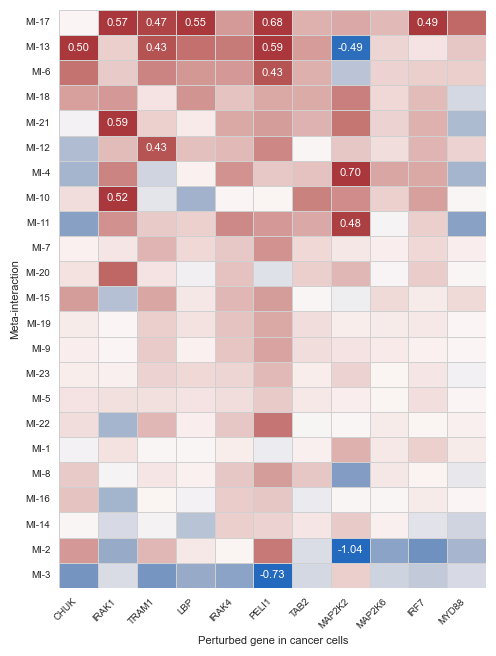

,MI-17,MI-13,MI-6,MI-18,MI-21,MI-12,MI-4,MI-10,MI-11,MI-7,...,MI-9,MI-23,MI-5,MI-22,MI-1,MI-8,MI-16,MI-14,MI-2,MI-3
CHUK,0.005246,0.500106,0.343812,0.228902,-0.031332,-0.202481,-0.225230,0.077933,-0.297149,0.026948,...,0.032802,0.038151,0.062347,0.077604,-0.034520,0.123067,0.139729,-0.006680,0.247754,-0.340167
IRAK1,0.565404,0.111990,0.123925,0.249720,0.593169,0.158107,0.302227,0.517459,0.268436,0.055176,...,0.006309,0.030231,0.069642,-0.224277,0.062501,-0.025734,-0.229202,-0.104728,-0.259364,-0.098292
TRAM1,0.468549,0.430218,0.302244,0.061594,0.105924,0.428946,-0.123697,-0.072106,0.124631,0.178208,...,0.119959,0.099833,0.068793,0.171742,-0.008093,0.054810,0.009765,-0.029987,0.171290,-0.337968
LBP,0.552449,0.354511,0.250431,0.261233,0.044165,0.150120,0.026371,-0.233066,0.107632,0.087503,...,0.024182,0.088237,0.060197,0.032634,-0.008198,0.027255,-0.034522,-0.177863,0.049179,-0.259761
IRAK4,0.245536,0.324250,0.249002,0.137782,0.208188,0.161349,0.262491,0.004845,0.285937,0.125636,...,0.136650,0.096481,0.076532,0.129085,0.036566,0.130617,0.115876,0.111067,0.011424,-0.285623


In [7]:
mi_change_pc2t, mi_change_t2pc = compute_mi_change_tables(
    Factor_envir=core_results["Factor_envir"],
    Factor_envir_dict=core_results["Factor_envir_dict"],
    perturb_gene_OI=perturb_gene_OI,
    perturbcancerTOTcell_edgerelindex_dict=core_results["perturbcancerTOTcell_edgerelindex_dict"],
    TcellTOTperturbcancer_edgerelindex_dict=core_results["TcellTOTperturbcancer_edgerelindex_dict"],
)

mi_change_pc2t.to_csv(base_run_dir / "MI_change_perturbcancerTOTcell_df.csv")
mi_change_t2pc.to_csv(base_run_dir / "MI_change_TcellTOTperturbcancer_df.csv")

plot_mi_change_heatmap(
    mi_change_df=mi_change_pc2t,
    save_prefix=base_run_dir / "Heatmap_MI_change_perturbcancer_to_Tcell",
    xlabel="Perturbed gene in cancer cells",
    ylabel="Meta-interaction",
    annotate_threshold=0.4,
    figsize=(5, 6.6),
    ifshow = True,
)
mi_change_pc2t.head()


## 8. Choose an MI of interest and inspect its top LR, receiver, and sender programs

In [8]:
# # MIOI = "MI10"
# MIOI = "MI8"

MIOI = "MI17"
# MIOI = "MI13"

feature_results = select_top_features_for_mi(
    MIOI=MIOI,
    loading_receiver_use_df=loading_receiver_use_df,
    loading_sender_use_df=loading_sender_use_df,
    loading_LR_use=loading_LR_use,
    LR_list=processed.lr_list,
    top_n=5,
)

LR_index_top = feature_results["LR_index_top"]
LR_list_top = feature_results["LR_list_top"]
targetgene_top = feature_results["targetgene_top"]
regulatorgene_top = feature_results["regulatorgene_top"]

print("Top LR indices:", LR_index_top)
print("Top LR pairs:", LR_list_top)
print("Top target genes:", targetgene_top)
print("Top regulator genes:", regulatorgene_top)


Top LR indices: [60, 87, 19, 95, 17, 35, 4, 102, 81, 105, 83]
Top LR pairs: [(('VEGFA',), ('VEGFA',)), (('VEGFA',), ('ITGB1',)), (('VEGFB',), ('VEGFA',)), (('NRP1',), ('VEGFA',)), (('ITGB1',), ('VEGFA',)), (('VEGFA',), ('NRP1',)), (('VEGFA',), ('VEGFC',)), (('VEGFA',), ('EGFR',)), (('VEGFA',), ('VEGFB',)), (('TGFB1',), ('VEGFA',)), (('COL5A1',), ('ITGB1',))]
Top target genes: ['VEGFA', 'EGR1', 'JUN', 'CDKN1A', 'PDK1', 'ATF3', 'TBX3', 'DKK1', 'IGF1R', 'PLOD2']
Top regulator genes: ['PDK1', 'VEGFA', 'ITGA5', 'SMAD2', 'LRP1', 'SERPINE1', 'CDKN1B', 'COL5A1']


## 9. Build perturb-edge vs. control-edge groups for the selected MI

The perturb-edge group consists of cancer→T-cell edges in which the cancer sender carries one of the MI-associated perturbations.
The control-edge group consists of cancer→T-cell edges from cancer cells without those perturbations.


In [9]:
perturb_gene_OI_choose = select_perturb_genes_for_mi(
    MIOI=MIOI,
    mi_change_pc2t=mi_change_pc2t,
)

edge_control_index_fromcancer_to_Tcell, edge_perturb_index_fromcancer_to_Tcell = build_edge_group_masks_for_selected_genes(
        adata_all=core_results["adata_all"],
        edge_index_all=core_results["edge_index_all"],
        perturb_annotation=core_results["perturb_annotation"],
        perturb_gene_OI_choose=perturb_gene_OI_choose,
    )

print("Selected perturbation genes for this MI:", perturb_gene_OI_choose)
print("Control edges:", len(edge_control_index_fromcancer_to_Tcell))
print("Perturb edges:", len(edge_perturb_index_fromcancer_to_Tcell))


Selected perturbation genes for this MI: ['IRAK1', 'TRAM1', 'LBP', 'PELI1', 'IRF7']
Control edges: 210985
Perturb edges: 1650


## 10. Compare the MI strength between perturb edges and control edges

D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\visualization.py:690: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


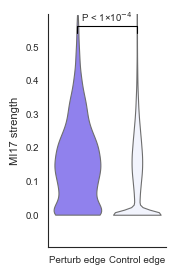

In [10]:
Factor_envir_df = pd.DataFrame(
    core_results["Factor_envir"],
    columns=[f"MI{i + 1}" for i in range(core_results["Factor_envir"].shape[1])],
)

x_control = Factor_envir_df.loc[
    edge_control_index_fromcancer_to_Tcell,
    MIOI,
].to_numpy(dtype=float)

x_perturb = Factor_envir_df.loc[
    edge_perturb_index_fromcancer_to_Tcell,
    MIOI,
].to_numpy(dtype=float)

plot_group_distribution(
    values_control=x_control,
    values_perturb=x_perturb,
    y_label=f"{MIOI} strength",
    save_prefix=base_run_dir / f"Violin_{MIOI}_strength_perturb_vs_control_edge",
    plot_kind="violin",
    ylim_top=0.9 if MIOI == "MI10" else None,
    ifshow=True,
)


## 11. Compare LR coexpression between perturb edges and control edges for the top LR pairs

In [11]:
LR_index_top

[60, 87, 19, 95, 17, 35, 4, 102, 81, 105, 83]

D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\visualization.py:703: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\visualization.py:703: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\visualization.py:703: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\visualization.py:703: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

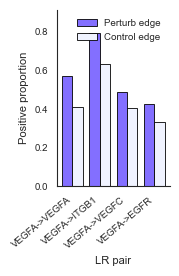

,LR_pair,Control_edge_positive_prop,Perturb_edge_positive_prop
0,VEGFA->VEGFA,0.413797,0.573939
1,VEGFA->ITGB1,0.633927,0.794545
2,VEGFA->VEGFC,0.404787,0.490909
3,VEGFA->EGFR,0.335138,0.425455


In [12]:
LR_index_top_use = np.array(LR_index_top)[[0,1,6,7]].tolist()
LR_coexpression = core_results["LR_coexpression"]

lr_positive_records = []

for LR_index_top_cur in LR_index_top_use:
    LR_top_cur = processed.lr_list[LR_index_top_cur]
    LR_top_cur_merge = "+".join(LR_top_cur[0]) + "->" + "+".join(LR_top_cur[1])
    LR_top_cur_merge1 = "+".join(LR_top_cur[0]) + "-" + "+".join(LR_top_cur[1])

    x_control = LR_coexpression[edge_control_index_fromcancer_to_Tcell, LR_index_top_cur].ravel()
    x_perturb = LR_coexpression[edge_perturb_index_fromcancer_to_Tcell, LR_index_top_cur].ravel()

    x_control = x_control[np.isfinite(x_control)]
    x_perturb = x_perturb[np.isfinite(x_perturb)]

    lr_positive_records.append(
        {
            "LR_pair": LR_top_cur_merge,
            "Control_edge_positive_prop": np.mean(x_control > 0),
            "Perturb_edge_positive_prop": np.mean(x_perturb > 0),
        }
    )

    plot_group_distribution(
        values_control=x_control,
        values_perturb=x_perturb,
        y_label=f"{LR_top_cur_merge} strength",
        save_prefix=base_run_dir / f"Boxplot_{MIOI}_{LR_top_cur_merge1}_strength_perturb_vs_control_edge",
        plot_kind="box",
        ylim_top=None,
    )

LR_positive_prop = pd.DataFrame(lr_positive_records)
LR_positive_prop.to_csv(base_run_dir / f"LR_positive_proportion_{MIOI}.csv", index=False)

plot_lr_positive_proportion_bar(
    df=LR_positive_prop,
    save_prefix=base_run_dir / f"Barplot_LR_positive_proportion_{MIOI}",
    ifshow=True,
)

LR_positive_prop


## 12. Compare target-gene expression between InControl_edge vs InPerturb_edge T cells

In [13]:
adata_all_subset = build_tcell_subset_from_edge_groups(
    adata_all=core_results["adata_all"],
    edge_index_all=core_results["edge_index_all"],
    edge_control_index_fromcancer_to_Tcell=edge_control_index_fromcancer_to_Tcell,
    edge_perturb_index_fromcancer_to_Tcell=edge_perturb_index_fromcancer_to_Tcell,
)

adata_all_subset


AnnData object with n_obs × n_vars = 37530 × 154
    obs: 'celltype', 'n_perturb', 'perturbation', 'n_counts', 'celltype2', 'sample_name', 'T cells_prop', 'cancer_prop', 'other_prop', 'Tcell_group'
    var: 'n_counts'
    uns: 'celltype2_colors', 'log1p', 'pca'
    obsm: 'X_pca', 'spatial'
    varm: 'PCs'

In [14]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


def _looks_like_counts(X, sample_n=2000):
    if sp.issparse(X):
        vals = X.data
        if vals.size == 0:
            return False
        vals = vals[: min(vals.size, sample_n)]
    else:
        X = np.asarray(X)
        flat = X.ravel()
        if flat.size == 0:
            return False
        vals = flat[np.random.choice(flat.size, size=min(sample_n, flat.size), replace=False)]

    nonneg = np.all(vals >= 0)
    near_int = np.mean(np.isclose(vals, np.round(vals)))
    vmax = float(np.max(vals)) if vals.size > 0 else 0.0
    return nonneg and near_int > 0.9 and vmax > 20


def prepare_target_gene_group_expression_analysis(
    adata,
    genes,
    group_key="Tcell_group",
    group_order=("InPerturb_edge", "InControl_edge"),
    layer_key="log1p_norm",
    alternative="greater",   # test whether InPerturb_edge > InControl_edge
    stats_csv_path=None,
    palette=None,
):
    if palette is None:
        palette = {
            "InControl_edge": "#F0F3FF",
            "InPerturb_edge": "#836FFF",
        }

    if group_key not in adata.obs.columns:
        raise KeyError(f"'{group_key}' not found in adata.obs")

    adata_use = adata[adata.obs[group_key].isin(group_order)].copy()
    adata_use.obs[group_key] = adata_use.obs[group_key].astype(str)

    present_groups = adata_use.obs[group_key].unique().tolist()
    missing_groups = [g for g in group_order if g not in present_groups]
    if len(missing_groups) > 0:
        raise ValueError(
            f"Missing groups in adata.obs['{group_key}']: {missing_groups}. "
            f"Present groups: {present_groups}"
        )

    genes_in = [g for g in genes if g in adata_use.var_names]
    genes_missing = [g for g in genes if g not in adata_use.var_names]

    if len(genes_in) == 0:
        raise ValueError("None of the requested genes are found in adata.var_names")

    # create layer if needed
    if layer_key not in adata_use.layers:
        if _looks_like_counts(adata_use.X):
            tmp = adata_use.copy()
            sc.pp.normalize_total(tmp, target_sum=1e4)
            sc.pp.log1p(tmp)
            adata_use.layers[layer_key] = tmp.X.copy()
            del tmp
        else:
            adata_use.layers[layer_key] = adata_use.X.copy()

    expr_df = sc.get.obs_df(adata_use, keys=genes_in, layer=layer_key)
    expr_df[group_key] = adata_use.obs[group_key].values

    pert = group_order[0]
    ctrl = group_order[1]

    records = []
    for gene in genes_in:
        x_pert = expr_df.loc[expr_df[group_key] == pert, gene].to_numpy(dtype=float)
        x_ctrl = expr_df.loc[expr_df[group_key] == ctrl, gene].to_numpy(dtype=float)

        x_pert = x_pert[np.isfinite(x_pert)]
        x_ctrl = x_ctrl[np.isfinite(x_ctrl)]

        if x_pert.size < 2 or x_ctrl.size < 2:
            stat, p = np.nan, np.nan
        else:
            stat, p = mannwhitneyu(x_pert, x_ctrl, alternative=alternative)

        records.append(
            {
                "gene": gene,
                "group_perturb": pert,
                "group_control": ctrl,
                "n_perturb": x_pert.size,
                "n_control": x_ctrl.size,
                "U": stat,
                "p_one_sided": p,
                "median_perturb": np.nanmedian(x_pert) if x_pert.size else np.nan,
                "median_control": np.nanmedian(x_ctrl) if x_ctrl.size else np.nan,
                "median_diff_perturb_minus_control": (
                    np.nanmedian(x_pert) - np.nanmedian(x_ctrl)
                    if (x_pert.size and x_ctrl.size) else np.nan
                ),
            }
        )

    stats_df = pd.DataFrame(records)

    valid = stats_df["p_one_sided"].notna().values
    q = np.full(stats_df.shape[0], np.nan, dtype=float)
    if valid.sum() > 0:
        q[valid] = multipletests(stats_df.loc[valid, "p_one_sided"].values, method="fdr_bh")[1]
    stats_df["q_fdr_bh"] = q

    if stats_csv_path is not None:
        stats_csv_path = Path(stats_csv_path)
        stats_csv_path.parent.mkdir(parents=True, exist_ok=True)
        stats_df.to_csv(stats_csv_path, index=False)

    return {
        "adata_use": adata_use,
        "expr_df": expr_df,
        "stats_df": stats_df,
        "genes_in": genes_in,
        "genes_missing": genes_missing,
        "group_order": list(group_order),
        "palette": palette,
        "layer_key": layer_key,
    }


def _p_to_star(p):
    if pd.isna(p):
        return "NA"
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def plot_target_gene_group_violins(
    expr_df,
    genes,
    group_key,
    group_order,
    palette,
    stats_df,
    save_prefix,
    genes_per_page=12,
    ncols=3,
    figsize_per_ax=(1.9, 2.9),
    violin_inner=None,
    violin_cut=0,
    violin_scale="width",
    show=True,
):
    genes = list(genes)
    if len(genes) == 0:
        return

    stat_map_p = dict(zip(stats_df["gene"], stats_df["p_one_sided"]))
    stat_map_q = dict(zip(stats_df["gene"], stats_df["q_fdr_bh"]))

    group_label_map = {
        "InPerturb_edge": "Perturb edge",
        "InControl_edge": "Control edge",
    }
    display_order = [group_label_map.get(g, g) for g in group_order]

    expr_plot = expr_df.copy()
    expr_plot[group_key] = expr_plot[group_key].map(group_label_map).fillna(expr_plot[group_key])

    n_pages = math.ceil(len(genes) / genes_per_page)

    for page in range(n_pages):
        genes_page = genes[page * genes_per_page : (page + 1) * genes_per_page]
        nrows = math.ceil(len(genes_page) / ncols)

        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(figsize_per_ax[0] * ncols, figsize_per_ax[1] * nrows),
            squeeze=False,
        )
        axes = axes.flatten()

        for ax_i, gene in enumerate(genes_page):
            ax = axes[ax_i]
            df_gene = expr_plot[[gene, group_key]].copy()
            df_gene.columns = ["expression", "group"]

            sns.violinplot(
                data=df_gene,
                x="group",
                y="expression",
                order=display_order,
                palette=[palette[group_order[0]], palette[group_order[1]]],
                inner=violin_inner,
                cut=violin_cut,
                scale=violin_scale,
                linewidth=1,
                ax=ax,
            )

            medians = (
                df_gene.groupby("group")["expression"]
                .median()
                .reindex(display_order)
            )
            for j, med in enumerate(medians):
                if pd.notna(med):
                    ax.hlines(
                        y=med,
                        xmin=j - 0.18,
                        xmax=j + 0.18,
                        colors="black",
                        linewidth=1.2,
                        zorder=5,
                    )

            p = stat_map_p.get(gene, np.nan)
            q = stat_map_q.get(gene, np.nan)

            ymax = np.nanmax(df_gene["expression"].values) if len(df_gene) else 1.0
            ymin = np.nanmin(df_gene["expression"].values) if len(df_gene) else 0.0
            yrng = max(ymax - ymin, 1e-6)

            line_y = ymax + 0.10 * yrng
            text_y = ymax + 0.16 * yrng

            ax.plot([0, 0, 1, 1], [line_y, line_y + 0.02 * yrng, line_y + 0.02 * yrng, line_y],
                    lw=1.0, c="black")
            ax.text(
                0.5,
                text_y,
                f"{_p_to_star(q)}\nq={q:.2e}" if pd.notna(q) else "NA",
                ha="center",
                va="bottom",
                fontsize=8,
            )

            ax.set_title(gene, fontsize=10, pad=6)
            ax.set_xlabel("")
            ax.set_ylabel("log1p normalized expression", fontsize=8)
            ax.tick_params(axis="x", labelrotation=20, labelsize=8)
            ax.tick_params(axis="y", labelsize=8)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        for j in range(len(genes_page), len(axes)):
            axes[j].axis("off")

        plt.tight_layout()

        save_prefix = Path(save_prefix)
        save_prefix.parent.mkdir(parents=True, exist_ok=True)

        if n_pages == 1:
            png_path = save_prefix.with_suffix(".png")
            pdf_path = save_prefix.with_suffix(".pdf")
        else:
            png_path = save_prefix.parent / f"{save_prefix.name}_page{page + 1}.png"
            pdf_path = save_prefix.parent / f"{save_prefix.name}_page{page + 1}.pdf"

        plt.savefig(png_path, dpi=300, bbox_inches="tight")
        plt.savefig(pdf_path, dpi=300, bbox_inches="tight")
        if show:
            plt.show()
        plt.close()

Genes found: ['VEGFA', 'EGR1', 'JUN', 'CDKN1A', 'PDK1', 'ATF3', 'TBX3', 'DKK1', 'IGF1R', 'PLOD2']
Genes missing: []


,gene,group_perturb,group_control,n_perturb,n_control,U,p_one_sided,median_perturb,median_control,median_diff_perturb_minus_control,q_fdr_bh
0,VEGFA,InPerturb_edge,InControl_edge,1559,35971,32632870.0,4.529810e-31,0.768182,0.510826,0.257357,4.529810e-30
4,PDK1,InPerturb_edge,InControl_edge,1559,35971,30662208.0,2.569514e-15,0.000000,0.000000,0.000000,1.284757e-14
8,IGF1R,InPerturb_edge,InControl_edge,1559,35971,29771077.0,4.715754e-11,0.000000,0.000000,0.000000,1.571918e-10
3,CDKN1A,InPerturb_edge,InControl_edge,1559,35971,29944555.0,8.757801e-11,0.000000,0.000000,0.000000,2.189450e-10
9,PLOD2,InPerturb_edge,InControl_edge,1559,35971,29895885.0,1.145614e-07,0.000000,0.000000,0.000000,2.291227e-07
5,ATF3,InPerturb_edge,InControl_edge,1559,35971,29370536.5,4.407627e-06,0.000000,0.000000,0.000000,7.346045e-06
6,TBX3,InPerturb_edge,InControl_edge,1559,35971,28877479.5,7.411161e-03,0.000000,0.000000,0.000000,1.058737e-02
1,EGR1,InPerturb_edge,InControl_edge,1559,35971,28529470.5,4.173449e-02,0.000000,0.000000,0.000000,5.216811e-02
2,JUN,InPerturb_edge,InControl_edge,1559,35971,28674662.5,6.212169e-02,0.904653,0.892529,0.012124,6.902411e-02
7,DKK1,InPerturb_edge,InControl_edge,1559,35971,28099769.5,4.149169e-01,0.000000,0.000000,0.000000,4.149169e-01


C:\Users\junji\AppData\Local\Temp\ipykernel_42236\777931637.py:208: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\junji\AppData\Local\Temp\ipykernel_42236\777931637.py:208: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\junji\AppData\Local\Temp\ipykernel_42236\777931637.py:208: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\junji\AppData\Local\Temp\ipykernel_42236\777931637.py:208: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\junji\A

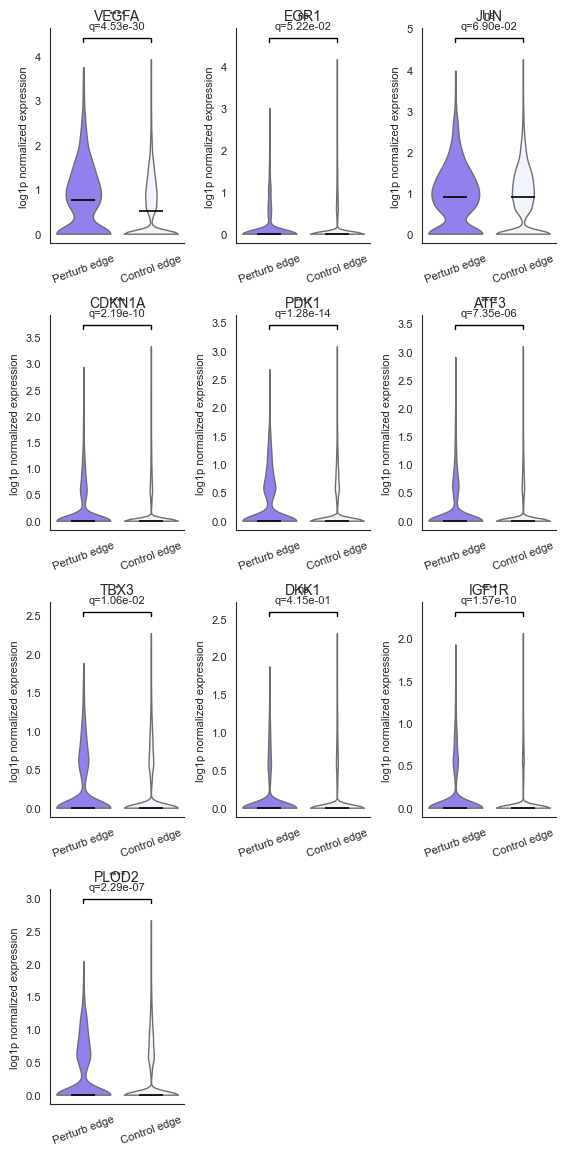

In [15]:
# Use the T-cell subset already created in cell 29
# adata_all_subset contains only:
#   - InControl_edge T cells
#   - InPerturb_edge T cells

target_genes_to_plot = targetgene_top.copy()   # or replace with your own list

target_gene_results = prepare_target_gene_group_expression_analysis(
    adata=adata_all_subset,
    genes=target_genes_to_plot,
    group_key="Tcell_group",
    group_order=("InPerturb_edge", "InControl_edge"),
    layer_key="log1p_norm",
    alternative="greater",   # InPerturb_edge > InControl_edge
    stats_csv_path=base_run_dir / f"{MIOI}_target_gene_Tcell_group_stats.csv",
    palette={
        "InPerturb_edge": "#836FFF",
        "InControl_edge": "#F0F3FF",
    },
)

print("Genes found:", target_gene_results["genes_in"])
print("Genes missing:", target_gene_results["genes_missing"])

display(
    target_gene_results["stats_df"].sort_values(
        ["q_fdr_bh", "median_diff_perturb_minus_control"],
        ascending=[True, False],
        na_position="last",
    )
)

plot_target_gene_group_violins(
    expr_df=target_gene_results["expr_df"],
    genes=target_gene_results["genes_in"],
    group_key="Tcell_group",
    group_order=target_gene_results["group_order"],
    palette=target_gene_results["palette"],
    stats_df=target_gene_results["stats_df"],
    save_prefix=base_run_dir / f"Violin_{MIOI}_target_genes_Tcell_InPerturb_vs_InControl",
    genes_per_page=12,
    ncols=3,
    figsize_per_ax=(1.9, 2.9),
    violin_inner=None,
    violin_cut=0,
    violin_scale="width",
    show=True,
)

## 13. Run GO enrichment for the top regulator and target genes of the MI of interest

In [16]:
go_res_reg = gp.enrichr(
    gene_list=regulatorgene_top,
    gene_sets=["GO_Biological_Process_2021"],
    organism="mouse",
    outdir=str(base_run_dir / f"GO_{MIOI}_regulators"),
    cutoff=0.05,
)
df_regulatory_enrich = go_res_reg.results[
    go_res_reg.results["Adjusted P-value"] < 0.05
].copy()

go_res_tar = gp.enrichr(
    gene_list=targetgene_top,
    gene_sets=["GO_Biological_Process_2021"],
    organism="mouse",
    outdir=str(base_run_dir / f"GO_{MIOI}_targets"),
    cutoff=0.05,
)
df_target_enrich = go_res_tar.results[
    go_res_tar.results["Adjusted P-value"] < 0.05
].copy()

df_regulatory_enrich.to_csv(base_run_dir / f"GO_{MIOI}_regulator_enrichment.csv", index=False)
df_target_enrich.to_csv(base_run_dir / f"GO_{MIOI}_target_enrichment.csv", index=False)

print("Top regulator enrichment results:")
display(df_regulatory_enrich.head(10))

print("Top target enrichment results:")
display(df_target_enrich.head(10))


Top regulator enrichment results:


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,"wound healing, spreading of epidermal cells (G...",2/8,0.000004,0.001246,0,0,1110.333333,13824.364138,COL5A1;ITGA5
1,GO_Biological_Process_2021,positive regulation of multicellular organisma...,4/345,0.000006,0.001246,0,0,57.627566,695.184389,SMAD2;LRP1;SERPINE1;VEGFA
2,GO_Biological_Process_2021,positive regulation of angiogenesis (GO:0045766),3/116,0.000010,0.001267,0,0,105.552212,1210.845245,SERPINE1;ITGA5;VEGFA
3,GO_Biological_Process_2021,negative regulation of smooth muscle cell migr...,2/14,0.000013,0.001267,0,0,555.000000,6256.612278,LRP1;SERPINE1
4,GO_Biological_Process_2021,positive regulation of sprouting angiogenesis ...,2/15,0.000015,0.001267,0,0,512.282051,5701.839075,ITGA5;VEGFA
5,GO_Biological_Process_2021,regulation of smooth muscle cell migration (GO...,2/20,0.000027,0.001636,0,0,369.888889,3897.964407,LRP1;SERPINE1
6,GO_Biological_Process_2021,eye morphogenesis (GO:0048592),2/20,0.000027,0.001636,0,0,369.888889,3897.964407,COL5A1;VEGFA
7,GO_Biological_Process_2021,"wound healing, spreading of cells (GO:0044319)",2/24,0.000038,0.002077,0,0,302.575758,3075.871223,COL5A1;ITGA5
8,GO_Biological_Process_2021,artery morphogenesis (GO:0048844),2/30,0.000061,0.002645,0,0,237.666667,2308.188874,LRP1;VEGFA
9,GO_Biological_Process_2021,extracellular structure organization (GO:0043062),3/216,0.000067,0.002645,0,0,55.715493,535.602904,COL5A1;SERPINE1;ITGA5


Top target enrichment results:


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,positive regulation of protein kinase activity...,4/154,6.847683e-07,0.000306,0,0,88.177778,1251.611715,EGR1;CDKN1A;DKK1;VEGFA
1,GO_Biological_Process_2021,positive regulation of tau-protein kinase acti...,2/6,3.371314e-06,0.000753,0,0,1249.125000,15739.234729,EGR1;DKK1
2,GO_Biological_Process_2021,negative regulation of binding (GO:0051100),3/88,9.658882e-06,0.000903,0,0,100.361345,1158.935942,JUN;CDKN1A;DKK1
3,GO_Biological_Process_2021,negative regulation of transcription by RNA po...,5/684,1.007212e-05,0.000903,0,0,28.440353,327.227280,JUN;DKK1;ATF3;TBX3;VEGFA
4,GO_Biological_Process_2021,regulation of tau-protein kinase activity (GO:...,2/10,1.010328e-05,0.000903,0,0,624.437500,7182.686017,EGR1;DKK1
5,GO_Biological_Process_2021,regulation of apoptotic process (GO:0042981),5/742,1.496135e-05,0.000975,0,0,26.123474,290.232844,JUN;DKK1;TBX3;VEGFA;IGF1R
6,GO_Biological_Process_2021,regulation of cell population proliferation (G...,5/764,1.724013e-05,0.000975,0,0,25.337286,277.906212,JUN;CDKN1A;TBX3;VEGFA;IGF1R
7,GO_Biological_Process_2021,regulation of transcription by RNA polymerase ...,7/2206,1.745384e-05,0.000975,0,0,18.877823,206.824504,EGR1;JUN;CDKN1A;DKK1;ATF3;TBX3;VEGFA
8,GO_Biological_Process_2021,negative regulation of programmed cell death (...,4/381,2.486010e-05,0.001235,0,0,34.682582,367.713276,DKK1;TBX3;VEGFA;IGF1R
9,GO_Biological_Process_2021,positive regulation of transcription by RNA po...,5/908,3.971627e-05,0.001729,0,0,21.137320,214.200308,EGR1;JUN;ATF3;TBX3;VEGFA


In [17]:
print(df_regulatory_enrich["Term"].tolist())

['wound healing, spreading of epidermal cells (GO:0035313)', 'positive regulation of multicellular organismal process (GO:0051240)', 'positive regulation of angiogenesis (GO:0045766)', 'negative regulation of smooth muscle cell migration (GO:0014912)', 'positive regulation of sprouting angiogenesis (GO:1903672)', 'regulation of smooth muscle cell migration (GO:0014910)', 'eye morphogenesis (GO:0048592)', 'wound healing, spreading of cells (GO:0044319)', 'artery morphogenesis (GO:0048844)', 'extracellular structure organization (GO:0043062)', 'external encapsulating structure organization (GO:0045229)', 'regulation of sprouting angiogenesis (GO:1903670)', 'positive regulation of receptor-mediated endocytosis (GO:0048260)', 'positive regulation of endocytosis (GO:0045807)', 'extracellular matrix organization (GO:0030198)', 'positive regulation of leukocyte chemotaxis (GO:0002690)', 'negative regulation of peptidase activity (GO:0010466)', 'positive regulation of cell death (GO:0010942)',

In [18]:
print(df_target_enrich["Term"].tolist())

['positive regulation of protein kinase activity (GO:0045860)', 'positive regulation of tau-protein kinase activity (GO:1902949)', 'negative regulation of binding (GO:0051100)', 'negative regulation of transcription by RNA polymerase II (GO:0000122)', 'regulation of tau-protein kinase activity (GO:1902947)', 'regulation of apoptotic process (GO:0042981)', 'regulation of cell population proliferation (GO:0042127)', 'regulation of transcription by RNA polymerase II (GO:0006357)', 'negative regulation of programmed cell death (GO:0043069)', 'positive regulation of transcription by RNA polymerase II (GO:0045944)', 'mesoderm development (GO:0007498)', 'negative regulation of transcription, DNA-templated (GO:0045892)', 'positive regulation of cell population proliferation (GO:0008284)', 'mammary gland development (GO:0030879)', 'positive regulation of transcription from RNA polymerase II promoter in response to stress (GO:0036003)', 'negative regulation of apoptotic process (GO:0043066)', 'c

## 14. Save a compact session manifest

This makes it easier for downstream notebooks to locate the main analysis outputs generated in this Part 1 run.


In [19]:
manifest = {
    "processed_data_dir": str(processed_data_dir),
    "base_run_dir": str(base_run_dir),
    "model_dir": str(base_model_dir),
    "summary_path": str(base_run_dir / "Part1_insilico_spatial_perturbation_summary.csv"),
    "golden_lfc_path": str(base_run_dir / "Part1_LFC_Tcell_golden.csv"),
    "predicted_lfc_path": str(base_run_dir / "Part1_LFC_Tcell_predicted.csv"),
    "mi_change_pc2t_path": str(base_run_dir / "MI_change_perturbcancerTOTcell_df.csv"),
    "mi_change_t2pc_path": str(base_run_dir / "MI_change_TcellTOTperturbcancer_df.csv"),
}

with open(base_run_dir / "part1_output_manifest.json", "w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2)

manifest


{'processed_data_dir': 'D:\\SpiderNet\\Results\\PerturbFISH\\ProcessedData',
 'base_run_dir': 'D:\\SpiderNet\\Results\\PerturbFISH\\V1\\SpiderNet_Result_dim23',
 'model_dir': 'D:\\SpiderNet\\Results\\PerturbFISH\\V1\\SpiderNet_Result_dim23\\Model',
 'summary_path': 'D:\\SpiderNet\\Results\\PerturbFISH\\V1\\SpiderNet_Result_dim23\\Part1_insilico_spatial_perturbation_summary.csv',
 'golden_lfc_path': 'D:\\SpiderNet\\Results\\PerturbFISH\\V1\\SpiderNet_Result_dim23\\Part1_LFC_Tcell_golden.csv',
 'predicted_lfc_path': 'D:\\SpiderNet\\Results\\PerturbFISH\\V1\\SpiderNet_Result_dim23\\Part1_LFC_Tcell_predicted.csv',
 'mi_change_pc2t_path': 'D:\\SpiderNet\\Results\\PerturbFISH\\V1\\SpiderNet_Result_dim23\\MI_change_perturbcancerTOTcell_df.csv',
 'mi_change_t2pc_path': 'D:\\SpiderNet\\Results\\PerturbFISH\\V1\\SpiderNet_Result_dim23\\MI_change_TcellTOTperturbcancer_df.csv'}